# Transactions data analysis

## Part 1 (ad-hoc)

In [163]:
import pandas as pd

In [164]:
retail = pd.read_csv('data.csv',encoding= 'unicode_escape')
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [165]:
# Check if the data contains duplicate records. How many are there?
print(f"Shape original data: rows - {retail.shape[0]}, columns - {retail.shape[1]}")


duplicated_rows = retail.loc[retail.duplicated()].shape[0]
print(f"Duplicated rows - {duplicated_rows}")


retail_cleaned = retail.drop_duplicates()
print(f"Shape after removing duplicates: rows - {retail_cleaned.shape[0]}, columns - {retail_cleaned.shape[1]}")


Shape original data: rows - 541909, columns - 8
Duplicated rows - 5268
Shape after removing duplicates: rows - 536641, columns - 8


In [166]:
# How many transactions were canceled by users?
retail_cleaned.InvoiceNo.str.startswith('C').sum()

9251

In [167]:
retail = retail_cleaned.loc[~retail.InvoiceNo.str.startswith('C')]

In [168]:
# identify the users from Germany who have made a significant number of orders,
# more than a certain threshold N(80th percentile)

invoice_dist = retail.query('Country == "Germany"')\
                .groupby('CustomerID', as_index=False)\
                .agg({'InvoiceNo':'nunique'})\
                .rename(columns={'InvoiceNo':'total_invoices'})
invoice_dist.head()

,CustomerID,total_invoices
0,12426.0,1
1,12427.0,3
2,12468.0,2
3,12471.0,30
4,12472.0,7


In [169]:
N = invoice_dist.total_invoices.quantile(q=0.8)
N

7.0

In [170]:
germany_top = invoice_dist.loc[invoice_dist.total_invoices > N]['CustomerID']
germany_top

3     12471.0
6     12474.0
8     12476.0
12    12481.0
16    12500.0
26    12524.0
37    12569.0
44    12600.0
51    12619.0
52    12621.0
56    12626.0
64    12647.0
69    12662.0
77    12705.0
78    12708.0
79    12709.0
81    12712.0
83    12720.0
Name: CustomerID, dtype: float64

In [171]:
# took the records from the retail dataframe for the users of interest, 
# whose IDs are stored in the germany_top variable.

top_retail_germany = retail.loc[retail.CustomerID.isin(germany_top)]
top_retail_germany.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
1109,536527,22809,SET OF 6 T-LIGHTS SANTA,6,12/1/2010 13:04,2.95,12662.0,Germany
1110,536527,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,6,12/1/2010 13:04,2.55,12662.0,Germany
1111,536527,84945,MULTI COLOUR SILVER T-LIGHT HOLDER,12,12/1/2010 13:04,0.85,12662.0,Germany
1112,536527,22242,5 HOOK HANGER MAGIC TOADSTOOL,12,12/1/2010 13:04,1.65,12662.0,Germany
1113,536527,22244,3 HOOK HANGER MAGIC GARDEN,12,12/1/2010 13:04,1.95,12662.0,Germany


In [172]:
# defined which item was added most frequently to the cart by active users from Germany, 
# disregarding the quantity of items

top_retail_germany.StockCode.value_counts()

StockCode
POST     213
22326     52
22328     38
22423     34
20719     30
        ... 
21564      1
22584      1
22561      1
21497      1
23562      1
Name: count, Length: 1158, dtype: int64

In [173]:
# found the top 5 orders with the highest revenue.
retail = retail.assign(Revenue = retail.UnitPrice * retail.Quantity)
retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34


In [174]:
top_revenue = retail.groupby('InvoiceNo', as_index=False)\
    .agg({'Revenue':'sum'})\
    .rename(columns={'Revenue':'TotalRevenue'})\
    .sort_values('TotalRevenue', ascending=False)\
    .head()
top_revenue

,InvoiceNo,TotalRevenue
22025,581483,168469.60
2303,541431,77183.60
18776,574941,52940.94
19468,576365,50653.91
9741,556444,38970.00


In [175]:
top_revenue['InvoiceNo'].values

array(['581483', '541431', '574941', '576365', '556444'], dtype=object)

## Part 2

In [176]:
# defined how many missing values are in the transaction_data.csv

In [177]:
transaction = pd.read_csv('transaction_data.csv')
transaction.head()

,date,name,transaction
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled
1,2020-03-02 00:59:09,Irina_Fedorova,successfull
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled


In [178]:
print(f"Shape transaction data: rows - {transaction.shape[0]}, columns - {transaction.shape[1]}")

Shape transaction data: rows - 5315, columns - 3


In [179]:
transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5315 entries, 0 to 5314
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   date         5315 non-null   object
 1   name         5315 non-null   object
 2   transaction  5315 non-null   object
dtypes: object(3)
memory usage: 124.7+ KB


In [180]:
transaction.describe()

,date,name,transaction
count,5315,5315,5315
unique,3373,56,3
top,2020-03-02 00:33:10,Masha_Ozerova,successfull
freq,6,112,3692


In [181]:
transaction.isna().sum()

date           0
name           0
transaction    0
dtype: int64

In [182]:
#  analyzed user transactions from the perspective of transaction status
trans_status = data.transaction.value_counts()
trans_status

transaction
successfull    3692
cancelled      1619
error             4
Name: count, dtype: int64

In [183]:
import seaborn as sns

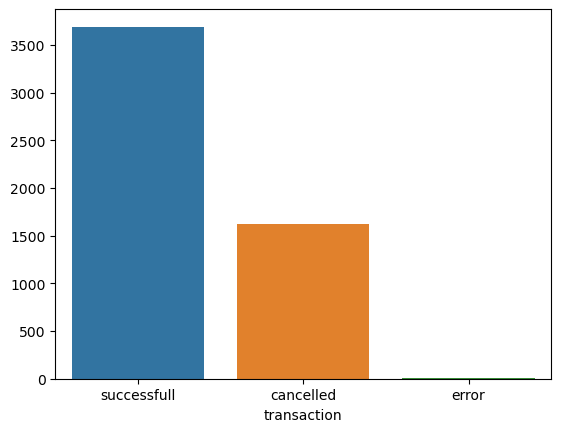

In [184]:
sns.barplot(x=trans_status.index, y=trans_status.values)
xlabel='transaction'

In [185]:
# calculated how many successful transactions each user made

success_per_user = data.loc[data.transaction == "successfull"].groupby('name', as_index=False).size()
success_per_user.describe()

,size
count,56.000000
mean,65.928571
std,7.787769
min,46.000000
25%,61.000000
50%,64.000000
75%,72.000000
max,82.000000


In [186]:
# on average, users made approximately 66 transactions
# the maximum number of transactions is 82
# about 25% of users made fewer than 61 transactions

c:\Users\alikp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


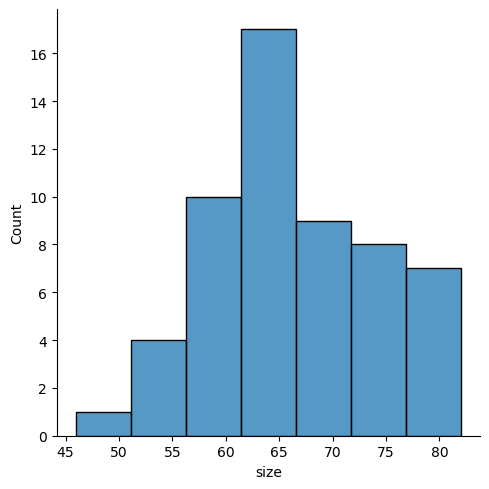

In [187]:
sns.displot(data=success_per_user, x='size')

In [188]:
# calculate the number of operations each user performed per minute 
# during the observed time period from transaction_data_updated.csv

transaction_data_updated = pd.read_csv('transaction_data_updated.csv', parse_dates=['date'])
transaction_data_updated.head()

,date,name,transaction,minute
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled,37
1,2020-03-02 00:59:09,Irina_Fedorova,successfull,59
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull,6
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled,2
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled,17


In [189]:
transaction_data_updated.shape

(5315, 4)

In [190]:
trans_per_minute = df.groupby(['name', 'minute'], as_index=False).size()
trans_per_minute.head()

,name,minute,size
0,Ekaterina_Fedorova,0,3
1,Ekaterina_Fedorova,1,4
2,Ekaterina_Fedorova,2,1
3,Ekaterina_Fedorova,3,3
4,Ekaterina_Fedorova,4,3


In [191]:
# use pivot
pivot_trans_per_min = trans_per_minute.pivot(index='minute', columns='name', values='size')
pivot_trans_per_min.head()

name,Ekaterina_Fedorova,Ekaterina_Ivanova,Ekaterina_Lesnova,Ekaterina_Ozerova,Ekaterina_Petrova,Ekaterina_Polyanova,Ekaterina_Smirnova,Irina_Fedorova,Irina_Ivanova,Irina_Lesnova,...,Svetlana_Petrova,Svetlana_Polyanova,Svetlana_Smirnova,Vasilisa_Fedorova,Vasilisa_Ivanova,Vasilisa_Lesnova,Vasilisa_Ozerova,Vasilisa_Petrova,Vasilisa_Polyanova,Vasilisa_Smirnova
minute,,,,,,,,,,,,,,,,,,,,,
0,3.0,4.0,2.0,3.0,4.0,4.0,2.0,1.0,2.0,2.0,...,NaN,3.0,1.0,1.0,4.0,1.0,3.0,NaN,NaN,1.0
1,4.0,4.0,NaN,4.0,2.0,5.0,4.0,4.0,4.0,3.0,...,4.0,5.0,3.0,2.0,3.0,3.0,NaN,NaN,3.0,2.0
2,1.0,2.0,4.0,4.0,2.0,1.0,3.0,2.0,3.0,3.0,...,4.0,1.0,3.0,3.0,NaN,1.0,2.0,1.0,3.0,1.0
3,3.0,NaN,2.0,NaN,5.0,2.0,1.0,3.0,2.0,2.0,...,1.0,5.0,5.0,2.0,4.0,NaN,3.0,4.0,1.0,NaN
4,3.0,NaN,NaN,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,1.0,2.0,2.0,1.0,1.0,2.0,2.0,3.0,NaN,1.0


In [192]:
# replase Nan
pivot_trans_per_min = pivot_trans_per_min.fillna(0)
pivot_trans_per_min.head()

name,Ekaterina_Fedorova,Ekaterina_Ivanova,Ekaterina_Lesnova,Ekaterina_Ozerova,Ekaterina_Petrova,Ekaterina_Polyanova,Ekaterina_Smirnova,Irina_Fedorova,Irina_Ivanova,Irina_Lesnova,...,Svetlana_Petrova,Svetlana_Polyanova,Svetlana_Smirnova,Vasilisa_Fedorova,Vasilisa_Ivanova,Vasilisa_Lesnova,Vasilisa_Ozerova,Vasilisa_Petrova,Vasilisa_Polyanova,Vasilisa_Smirnova
minute,,,,,,,,,,,,,,,,,,,,,
0,3.0,4.0,2.0,3.0,4.0,4.0,2.0,1.0,2.0,2.0,...,0.0,3.0,1.0,1.0,4.0,1.0,3.0,0.0,0.0,1.0
1,4.0,4.0,0.0,4.0,2.0,5.0,4.0,4.0,4.0,3.0,...,4.0,5.0,3.0,2.0,3.0,3.0,0.0,0.0,3.0,2.0
2,1.0,2.0,4.0,4.0,2.0,1.0,3.0,2.0,3.0,3.0,...,4.0,1.0,3.0,3.0,0.0,1.0,2.0,1.0,3.0,1.0
3,3.0,0.0,2.0,0.0,5.0,2.0,1.0,3.0,2.0,2.0,...,1.0,5.0,5.0,2.0,4.0,0.0,3.0,4.0,1.0,0.0
4,3.0,0.0,0.0,3.0,1.0,1.0,2.0,3.0,2.0,1.0,...,1.0,2.0,2.0,1.0,1.0,2.0,2.0,3.0,0.0,1.0


In [193]:
minute_trans = pivot_trans_per_min.sum(axis=1)
minute_trans.head()

minute
0    111.0
1    145.0
2    123.0
3    129.0
4     92.0
dtype: float64

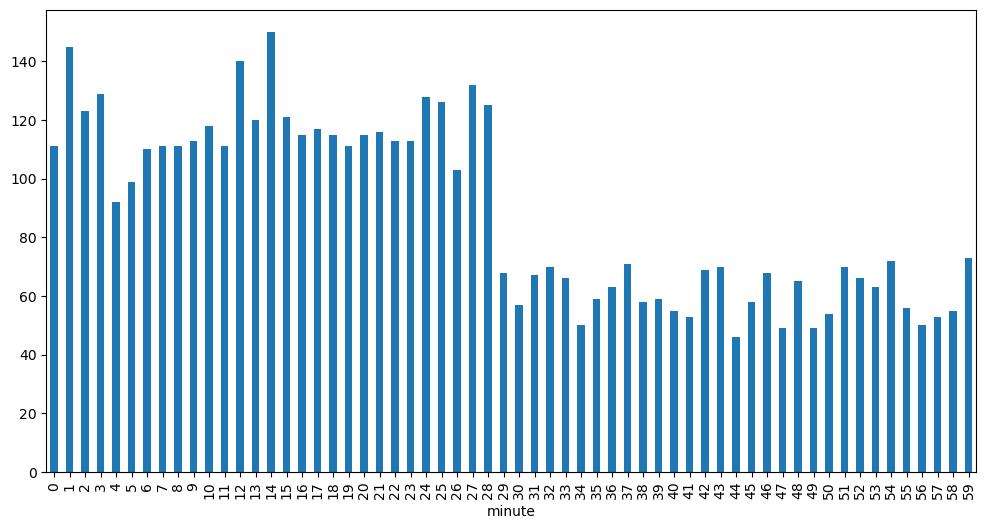

In [198]:
minute_trans.plot.bar(figsize=(12,6))
xlabel='minute'

In [199]:
transaction_data_updated['true_minute'] = transaction_data_updated.date.dt.minute + transaction_data_updated.date.dt.hour * 60
transaction_data_updated.head()

,date,name,transaction,minute,date_numeric,true_minute
0,2020-03-02 00:37:20,Ekaterina_Petrova,cancelled,37,1583109440,37
1,2020-03-02 00:59:09,Irina_Fedorova,successfull,59,1583110749,59
2,2020-03-02 01:06:14,Ekaterina_Smirnova,successfull,6,1583111174,66
3,2020-03-02 00:02:58,Lolita_Polyanova,cancelled,2,1583107378,2
4,2020-03-02 00:17:52,Julia_Smirnova,cancelled,17,1583108272,17


c:\Users\alikp\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


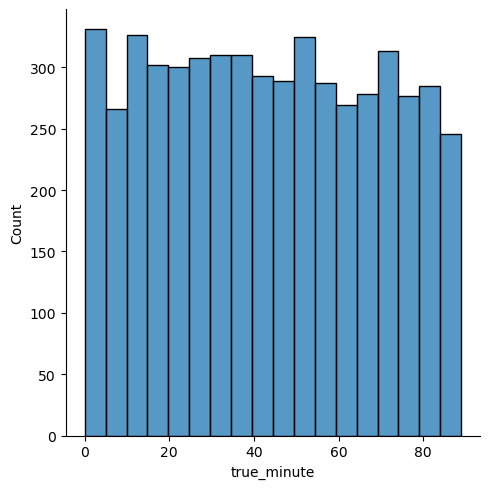

In [201]:
sns.displot(data=transaction_data_updated, x='true_minute')

In [ ]:
# the problem with the plot.bar was that I extracted the minute part of the time
# instead of the number of minutes since the start of the day